Q.1 :
- Create a dataset with mixed columns:
- Age (numeric)
- Salary (numeric with missing values)
- Gender (categorical)
- Education (ordinal: High School, Graduate, Postgraduate)
- Handle missing numeric values (e.g., median imputation).
- Encode categorical variable with One-Hot Encoding.
- Encode ordinal variable with an ordered mapping.
- Merge back into a clean DataFrame.

In [1]:
import pandas as pd
import numpy as np

# Step 1: Create dataset
data = {
    'Age': [25, 30, 35, 40, 28],
    'Salary': [30000, np.nan, 50000, 60000, np.nan],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Male'],
    'Education': ['Graduate', 'Postgraduate', 'High School', 'Graduate', 'Postgraduate']
}

df = pd.DataFrame(data)

print("Original Data:\n", df)

# Step 2: Handle missing values (median)
df['Salary'].fillna(df['Salary'].median(), inplace=True)

# Step 3: One-Hot Encoding (Gender)
df_encoded = pd.get_dummies(df, columns=['Gender'])

# Step 4: Ordinal Encoding (Education)
education_map = {
    'High School': 1,
    'Graduate': 2,
    'Postgraduate': 3
}

df_encoded['Education'] = df_encoded['Education'].map(education_map)

# Step 5: Final dataset
print("\nCleaned Data:\n", df_encoded)

Original Data:
    Age   Salary  Gender     Education
0   25  30000.0    Male      Graduate
1   30      NaN  Female  Postgraduate
2   35  50000.0  Female   High School
3   40  60000.0    Male      Graduate
4   28      NaN    Male  Postgraduate

Cleaned Data:
    Age   Salary  Education  Gender_Female  Gender_Male
0   25  30000.0          2          False         True
1   30  50000.0          3           True        False
2   35  50000.0          1           True        False
3   40  60000.0          2          False         True
4   28  50000.0          3          False         True


C:\Users\Admin\AppData\Local\Temp\ipykernel_23460\2973470830.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(df['Salary'].median(), inplace=True)


Q.2 : Create a dataset with columns: OrderID, OrderDate, Delivery Date.
- Convert OrderDate and DeliveryDate to datetime format.

Extract:
- Year, Month, Day from OrderDate
- Delivery duration = DeliveryDate - OrderDate (in days)
- Add a feature for weekday vs weekend orders.
- Visualize monthly order counts with a bar chart.

   OrderID   OrderDate DeliveryDate
0        1  2024-01-05   2024-01-08
1        2  2024-01-10   2024-01-15
2        3  2024-02-15   2024-02-18
3        4  2024-02-20   2024-02-25
4        5  2024-03-01   2024-03-05
5        6  2024-03-10   2024-03-14
6        7  2024-04-05   2024-04-10
7        8  2024-04-15   2024-04-18
8        9  2024-05-01   2024-05-05
9       10  2024-05-12   2024-05-15


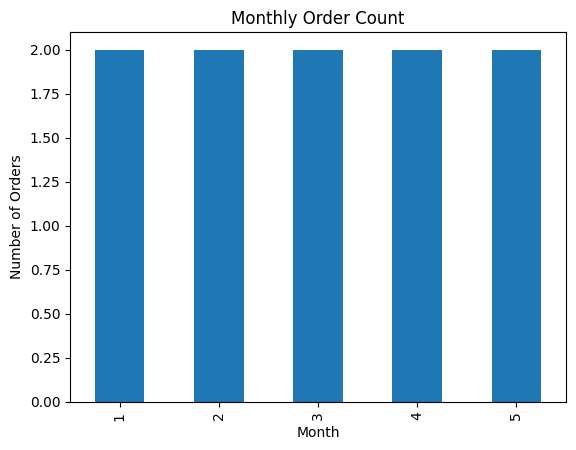

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create sample data
data = {
    'OrderID': range(1, 11),
    'OrderDate': [
        '2024-01-05', '2024-01-10', '2024-02-15', '2024-02-20',
        '2024-03-01', '2024-03-10', '2024-04-05', '2024-04-15',
        '2024-05-01', '2024-05-12'
    ],
    'DeliveryDate': [
        '2024-01-08', '2024-01-15', '2024-02-18', '2024-02-25',
        '2024-03-05', '2024-03-14', '2024-04-10', '2024-04-18',
        '2024-05-05', '2024-05-15'
    ]
}

df = pd.DataFrame(data)

print(df)

#Step 2: Convert date and delivery date to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'], errors='coerce')


# Step 3: Extract Year Month Day from order date
df['Year'] = df['OrderDate'].dt.year
df['day'] = df['OrderDate'].dt.day
df['month'] = df['OrderDate'].dt.month

#Step 4: Calculate delivery duration
df['DeliveryDuration'] = df['DeliveryDate'].dt.day - df['OrderDate'].dt.day

#Step 5 : Create a new feature to indicate if the order was placed on a weekend
df['Weekday'] = df['OrderDate'].dt.weekday
df['Is_Weekend'] = df['Weekday'].apply(lambda x: 1 if x >= 5 else 0)

#Step 6: visualize the distribution of delivery durations
monthly_orders = df.groupby(df['month'])['OrderID'].count()

plt.figure()
monthly_orders.plot(kind='bar')

plt.title("Monthly Order Count")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()


Q.3 : 
- Load or create a dataset with missing values in multiple columns.
- Count how many rows contain at least one missing value.
- Apply complete case analysis: drop all rows with NaN.
- Compare dataset size before vs after dropping.
- Discuss the trade-off: data loss vs data quality.

In [7]:
import pandas as pd
import numpy as np

# Create dataset
data = {
    'Age': [25, 30, np.nan, 40, 28],
    'Salary': [30000, np.nan, 50000, 60000, np.nan],
    'Gender': ['Male', 'Female', np.nan, 'Male', 'Male']
}

df = pd.DataFrame(data)

print("Original Data:\n", df)
print("\nShape Before Dropping Missing Values:", df.shape)

#Counting missing values

print("\n Missing Valuses : \n",df.isna().sum())

#Complete Case Analysis
df_drop = df.dropna()

print("\nAfter Dropping Missing Values:\n", df_drop)
print("\nShape After Dropping Missing Values:", df_drop.shape)

Original Data:
     Age   Salary  Gender
0  25.0  30000.0    Male
1  30.0      NaN  Female
2   NaN  50000.0     NaN
3  40.0  60000.0    Male
4  28.0      NaN    Male

Shape Before Dropping Missing Values: (5, 3)

 Missing Valuses : 
 Age       1
Salary    2
Gender    1
dtype: int64

After Dropping Missing Values:
     Age   Salary Gender
0  25.0  30000.0   Male
3  40.0  60000.0   Male

Shape After Dropping Missing Values: (2, 3)
